# 🌿 Détection de Maladies des Plantes — EfficientNet-B3

## ⚠️ BUG CORRIGÉ : Double normalisation
L'ancienne version faisait `rescale=1/255` dans le générateur **ET** `preprocess_input` dans le modèle → pixels = ~0 → le modèle ne pouvait pas apprendre (accuracy bloquée à 18%).

**Fix** : On supprime le `rescale` et on laisse `preprocess_input` gérer seul.

| # | Cellule | Contenu |
|---|---------|--------|
| 1 | Installation | Installe gradio, kagglehub |
| 2 | Dataset | Téléchargement + split |
| 3 | Générateurs | flow_from_directory (0 RAM) |
| 4 | Modèle | EfficientNet-B3 |
| 5 | Phase 1 | Entraînement tête |
| 6 | Phase 2 | Fine-tuning |
| 7 | Courbes | Learning curves |
| 8 | Évaluation | Métriques + confusion matrix + ROC |
| 9 | Gradio | Interface interactive |

In [1]:
# ══════════════════════════════════════════════════════════════
# CELLULE 1 — Installation & Imports
# ══════════════════════════════════════════════════════════════

!pip install gradio -q
!pip install kagglehub -q

import os, time, warnings, random, shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, applications, optimizers, callbacks, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, f1_score
)
from sklearn.preprocessing import label_binarize

# ── Reproductibilité ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── GPU ───────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for g in gpus:
        tf.config.experimental.set_memory_growth(g, True)
    print(f'✅ GPU : {gpus[0].name}')
else:
    print('⚠️  CPU uniquement')

print(f'✅ TensorFlow {tf.__version__}')
print('✅ Imports OK')

⚠️  CPU uniquement
✅ TensorFlow 2.20.0
✅ Imports OK


In [2]:
# ══════════════════════════════════════════════════════════════
# CELLULE 2 — Téléchargement & Organisation du Dataset
# ══════════════════════════════════════════════════════════════

import kagglehub

print('📥 Téléchargement PlantVillage...')
raw_path = kagglehub.dataset_download('emmarex/plantdisease')
print(f'📂 Chemin brut : {raw_path}')

# ── Trouver le dossier qui contient les sous-dossiers de classes ──
DATASET_ROOT = None
for root, dirs, files in os.walk(raw_path):
    subdirs = [d for d in dirs if os.path.isdir(os.path.join(root, d))]
    if len(subdirs) >= 5:
        DATASET_ROOT = root
        break
assert DATASET_ROOT, 'Dataset root introuvable !'
print(f'✅ Dataset root : {DATASET_ROOT}')

# ── Classes sélectionnées (15 classes = Tomate + Poivron + Pomme de terre) ──
SELECTED = [
    'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy',
    'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy',
    'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight',
    'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot',
    'Tomato_Spider_mites_Two-spotted_spider_mite',
    'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus',
    'Tomato__Tomato_mosaic_virus', 'Tomato_healthy',
]

all_folders = sorted(os.listdir(DATASET_ROOT))

def match_class(name, folders):
    if name in folders:
        return name
    key = name.lower().replace(' ','').replace(',','').replace('_','')
    for f in folders:
        if key in f.lower().replace(' ','').replace(',','').replace('_',''):
            return f
        if f.lower().replace(' ','').replace(',','').replace('_','') in key:
            return f
    return None

CLASSES = []
for s in SELECTED:
    m = match_class(s, all_folders)
    if m and m not in CLASSES:
        CLASSES.append(m)
        print(f'  ✅ {m}')
    else:
        print(f'  ⚠️  Non trouvé : {s}')

NB_CLASSES = len(CLASSES)
print(f'\n✅ {NB_CLASSES} classes retenues')

# ── Stats ──────────────────────────────────────────────────────
total = sum(
    len([f for f in os.listdir(os.path.join(DATASET_ROOT, c))
         if f.lower().endswith(('.jpg','.jpeg','.png'))])
    for c in CLASSES
)
print(f'📊 Total images disponibles : {total:,}')

📥 Téléchargement PlantVillage...
Using Colab cache for faster access to the 'plantdisease' dataset.
📂 Chemin brut : /kaggle/input/plantdisease
✅ Dataset root : /kaggle/input/plantdisease/PlantVillage
  ✅ Pepper__bell___Bacterial_spot
  ✅ Pepper__bell___healthy
  ✅ Potato___Early_blight
  ✅ Potato___Late_blight
  ✅ Potato___healthy
  ✅ Tomato_Bacterial_spot
  ✅ Tomato_Early_blight
  ✅ Tomato_Late_blight
  ✅ Tomato_Leaf_Mold
  ✅ Tomato_Septoria_leaf_spot
  ⚠️  Non trouvé : Tomato_Spider_mites_Two-spotted_spider_mite
  ✅ Tomato__Target_Spot
  ✅ Tomato__Tomato_YellowLeaf__Curl_Virus
  ✅ Tomato__Tomato_mosaic_virus
  ✅ Tomato_healthy

✅ 14 classes retenues
📊 Total images disponibles : 18,962


📁 Création du split...
  Pepper__bell___Bacterial_spot              train= 699  val=149  test=149
  Pepper__bell___healthy                     train=1036  val=221  test=221
  Potato___Early_blight                      train= 700  val=150  test=150
  Potato___Late_blight                       train= 700  val=150  test=150
  Potato___healthy                           train= 108  val= 22  test= 22
  Tomato_Bacterial_spot                      train=1489  val=319  test=319
  Tomato_Early_blight                        train= 700  val=150  test=150
  Tomato_Late_blight                         train=1337  val=286  test=286
  Tomato_Leaf_Mold                           train= 668  val=142  test=142
  Tomato_Septoria_leaf_spot                  train=1241  val=265  test=265
  Tomato__Target_Spot                        train= 984  val=210  test=210
  Tomato__Tomato_YellowLeaf__Curl_Virus      train=2246  val=481  test=481
  Tomato__Tomato_mosaic_virus                train= 263  val= 55  test= 55
  

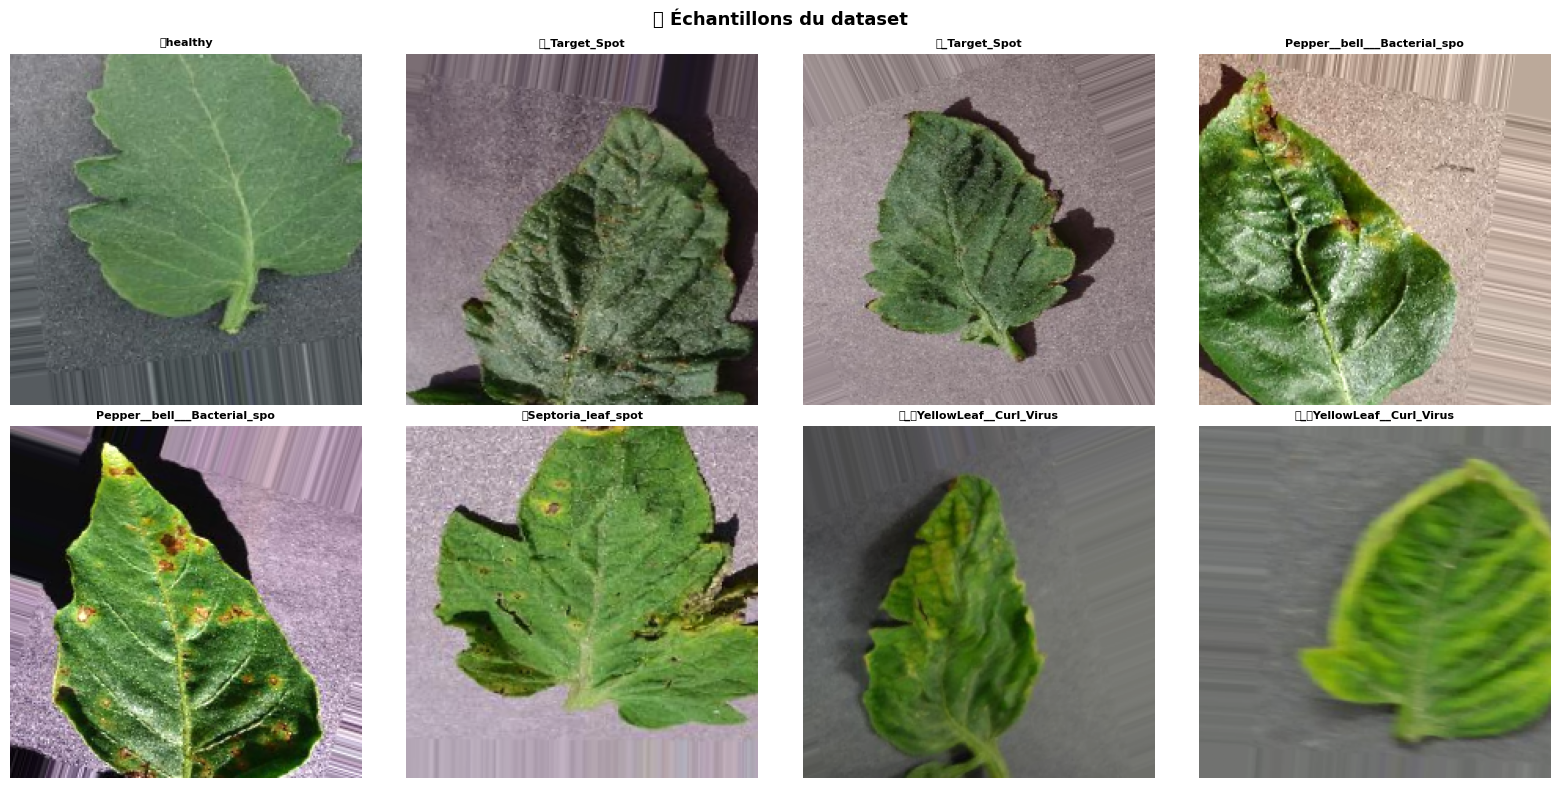

✅ samples.png sauvegardé


In [3]:
# ══════════════════════════════════════════════════════════════
# CELLULE 3 — Split + Générateurs (ZÉRO chargement RAM)
#
# 🔴 BUG CORRIGÉ ICI :
#    ANCIEN : rescale=1/255  + preprocess_input → double normalisation
#    CORRECT : PAS de rescale + preprocess_input dans le modèle
# ══════════════════════════════════════════════════════════════

SPLIT_ROOT  = '/content/plant_split'
IMG_SIZE    = 224
BATCH_SIZE  = 32     # T4 Colab a 15GB VRAM, 32 est parfait
TEST_FRAC   = 0.15
VAL_FRAC    = 0.15

# ── Créer le split (symlinks pour ne pas dupliquer les fichiers) ──
def build_split(dataset_root, classes, split_root, test_frac=0.15, val_frac=0.15, seed=42):
    if os.path.exists(split_root):
        n_existing = sum(
            len(os.listdir(os.path.join(split_root, 'train', c)))
            for c in classes if os.path.isdir(os.path.join(split_root, 'train', c))
        )
        if n_existing > 100:
            print(f'✅ Split existant utilisé ({split_root})')
            return
        shutil.rmtree(split_root)

    print('📁 Création du split...')
    random.seed(seed)
    for s in ['train','val','test']:
        for c in classes:
            os.makedirs(os.path.join(split_root, s, c), exist_ok=True)

    for cls in classes:
        src = os.path.join(dataset_root, cls)
        imgs = sorted([f for f in os.listdir(src)
                       if f.lower().endswith(('.jpg','.jpeg','.png'))])
        random.shuffle(imgs)
        n = len(imgs)
        n_test = int(n * test_frac)
        n_val  = int(n * val_frac)
        splits = {
            'test' : imgs[:n_test],
            'val'  : imgs[n_test:n_test+n_val],
            'train': imgs[n_test+n_val:]
        }
        for sname, slist in splits.items():
            dst_dir = os.path.join(split_root, sname, cls)
            for img in slist:
                src_f = os.path.abspath(os.path.join(src, img))
                dst_f = os.path.join(dst_dir, img)
                if not os.path.exists(dst_f):
                    try:
                        os.symlink(src_f, dst_f)
                    except OSError:
                        shutil.copy2(src_f, dst_f)
        print(f'  {cls[:42]:<42s} train={len(splits["train"]):4d}  val={len(splits["val"]):3d}  test={len(splits["test"]):3d}')
    print('✅ Split créé !')

build_split(DATASET_ROOT, CLASSES, SPLIT_ROOT)

# ══════════════════════════════════════════════════════════════
# ✅ CORRECTION CRITIQUE : PAS de rescale ici !
#    EfficientNet's preprocess_input attend [0, 255]
#    et fait la normalisation lui-même dans le modèle.
# ══════════════════════════════════════════════════════════════

train_datagen = ImageDataGenerator(
    # ❌ SUPPRIMÉ : rescale=1./255   ← c'était le bug !
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
)

val_test_datagen = ImageDataGenerator(
    # ❌ SUPPRIMÉ : rescale=1./255   ← idem
)

common = dict(
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASSES,
    seed=SEED,
)

train_gen = train_datagen.flow_from_directory(
    os.path.join(SPLIT_ROOT, 'train'), shuffle=True,  **common)
val_gen   = val_test_datagen.flow_from_directory(
    os.path.join(SPLIT_ROOT, 'val'),   shuffle=False, **common)
test_gen  = val_test_datagen.flow_from_directory(
    os.path.join(SPLIT_ROOT, 'test'),  shuffle=False, **common)

print(f'\n✅ Générateurs (images chargées à la volée, 0 RAM) :')
print(f'   Train : {train_gen.samples:,} images — {len(train_gen)} batches')
print(f'   Val   : {val_gen.samples:,} images — {len(val_gen)} batches')
print(f'   Test  : {test_gen.samples:,} images — {len(test_gen)} batches')

# ── Class weights ─────────────────────────────────────────────
from sklearn.utils.class_weight import compute_class_weight
y_train = train_gen.classes
cw = compute_class_weight('balanced', classes=np.arange(NB_CLASSES), y=y_train)
CLASS_WEIGHTS = {i: float(w) for i, w in enumerate(cw)}
print(f'\n⚖️  Class weights calculés ({NB_CLASSES} classes)')

# ── Visualisation quelques samples ───────────────────────────
batch_x, batch_y = next(train_gen)
# preprocess_input ramène en [-1,1] pour l'affichage on remet en [0,1]
sample_display = (batch_x[:8] / 255.0).clip(0, 1)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_display[i])
    lbl = int(np.argmax(batch_y[i]))
    short = CLASSES[lbl].replace('Tomato_','🍅').replace('Potato___','🥔').replace('Pepper,_bell___','🌶️')[:28]
    ax.set_title(short, fontsize=8, fontweight='bold')
    ax.axis('off')
plt.suptitle('🌿 Échantillons du dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/samples.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ samples.png sauvegardé')

In [4]:
# ══════════════════════════════════════════════════════════════
# CELLULE 4 — Construction du Modèle EfficientNet-B3
#
# preprocess_input est ici dans le modèle → reçoit [0,255] ✅
# ══════════════════════════════════════════════════════════════

WEIGHT_DECAY    = 1e-4
LABEL_SMOOTHING = 0.1
LR_PHASE1       = 1e-3
DROPOUT_RATES   = [0.4, 0.3]

def build_model(nb_classes, img_size=224, lr=1e-3):
    """
    Architecture :
      Input [0,255]
      → preprocess_input   ← normalisation EfficientNet
      → EfficientNet-B3 (gelé)
      → GAP
      → BN → Dropout(0.4) → Dense(512, relu)
      → BN → Dropout(0.3) → Dense(N, softmax)
    """
    # Base pré-entraînée
    base = applications.EfficientNetB3(
        include_top=False,
        weights='imagenet',
        input_shape=(img_size, img_size, 3),
        pooling=None
    )
    base.trainable = False
    print(f'✅ EfficientNet-B3 : {len(base.layers)} couches | gelées')

    # ── Entrée : attend des pixels [0, 255] ──────────────────
    inputs = keras.Input(shape=(img_size, img_size, 3), name='input_image')

    # ✅ preprocess_input normalise [0,255] → [-1, 1] pour EfficientNet
    x = applications.efficientnet.preprocess_input(inputs)
    x = base(x, training=False)

    # ── Tête de classification ─────────────────────────────────
    x = layers.GlobalAveragePooling2D(name='gap')(x)

    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Dropout(DROPOUT_RATES[0], name='drop1')(x)
    x = layers.Dense(
        512, activation='relu',
        kernel_regularizer=regularizers.l2(WEIGHT_DECAY),
        name='dense_512'
    )(x)

    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.Dropout(DROPOUT_RATES[1], name='drop2')(x)

    outputs = layers.Dense(nb_classes, activation='softmax',
                           dtype='float32', name='predictions')(x)

    model = keras.Model(inputs, outputs, name='PlantDisease_EffNetB3')

    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
        metrics=['accuracy']
    )

    trainable = sum(int(np.prod(v.shape)) for v in model.trainable_variables)
    total     = sum(int(np.prod(v.shape)) for v in model.variables)
    print(f'   Paramètres entraînables : {trainable:,}')
    print(f'   Paramètres gelés        : {total-trainable:,}')
    return model, base


model, base_model = build_model(NB_CLASSES, IMG_SIZE, LR_PHASE1)
model.summary()

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
✅ EfficientNet-B3 : 385 couches | gelées
   Paramètres entraînables : 798,222
   Paramètres gelés        : 10,787,673


Model: "PlantDisease_EffNetB3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 7, 7, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 1536)           │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_512 (Dense)               │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 14)             │         7,182 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,585,853 (44.20 MB)

 Trainable params: 798,222 (3.04 MB)

 Non-trainable params: 10,787,631 (41.15 MB)

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELLULE 5 — Phase 1 : Entraînement de la tête (base gelée)
# ══════════════════════════════════════════════════════════════

EPOCHS_P1        = 15
MODEL_P1_PATH    = '/content/best_model_phase1.keras'
LOG_PATH         = '/content/training_log.csv'

cbs_p1 = [
    callbacks.ModelCheckpoint(
        MODEL_P1_PATH, monitor='val_accuracy',
        save_best_only=True, mode='max', verbose=1),
    callbacks.EarlyStopping(
        monitor='val_loss', patience=7,
        restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.3,
        patience=4, min_lr=1e-7, verbose=1),
    callbacks.CSVLogger(LOG_PATH),
]

print('='*60)
print('🚀 PHASE 1 — Tête seulement (base EfficientNet gelée)')
print(f'   LR={LR_PHASE1}  |  Epochs={EPOCHS_P1}  |  Batch={BATCH_SIZE}')
print('='*60)

t0 = time.time()
history_p1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_P1,
    callbacks=cbs_p1,
    class_weight=CLASS_WEIGHTS,
    verbose=1
)
elapsed = (time.time() - t0) / 60

best_p1 = max(history_p1.history['val_accuracy'])
print(f'\n✅ Phase 1 terminée en {elapsed:.1f} min')
print(f'   Meilleure val_accuracy : {best_p1*100:.2f}%')

🚀 PHASE 1 — Tête seulement (base EfficientNet gelée)
   LR=0.001  |  Epochs=15  |  Batch=32
Epoch 1/15
215/416 ━━━━━━━━━━━━━━━━━━━━ 16:02 5s/step - accuracy: 0.5201 - loss: 2.1092

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELLULE 6 — Phase 2 : Fine-Tuning
# ══════════════════════════════════════════════════════════════

LR_PHASE2      = 1e-5
EPOCHS_P2      = 20
FINE_TUNE_AT   = 100   # Dégeler les 100 dernières couches
MODEL_FINAL    = '/content/best_model_final.keras'

# ── Charger le meilleur modèle Phase 1 ──────────────────────
model = keras.models.load_model(MODEL_P1_PATH)
print(f'✅ Modèle Phase 1 chargé : {MODEL_P1_PATH}')

# ── Trouver la base EfficientNet ─────────────────────────────
base_model = next(
    (l for l in model.layers if 'efficientnet' in l.name.lower()), None
)
assert base_model is not None, 'Base model introuvable !'

# ── Dégeler les N dernières couches ──────────────────────────
base_model.trainable = True
total_layers = len(base_model.layers)
for layer in base_model.layers[:total_layers - FINE_TUNE_AT]:
    layer.trainable = False
n_unfreeze = sum(1 for l in base_model.layers if l.trainable)
print(f'   Couches dégelées : {n_unfreeze} / {total_layers}')

# ── Recompiler avec LR très faible ───────────────────────────
model.compile(
    optimizer=optimizers.Adam(learning_rate=LR_PHASE2),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

cbs_p2 = [
    callbacks.ModelCheckpoint(
        MODEL_FINAL, monitor='val_accuracy',
        save_best_only=True, mode='max', verbose=1),
    callbacks.EarlyStopping(
        monitor='val_loss', patience=7,
        restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.3,
        patience=4, min_lr=1e-8, verbose=1),
    callbacks.CSVLogger(LOG_PATH, append=True),
]

print('='*60)
print('🔬 PHASE 2 — Fine-Tuning')
print(f'   LR={LR_PHASE2}  |  Epochs={EPOCHS_P2}  |  Couches dégelées={FINE_TUNE_AT}')
print('='*60)

t0 = time.time()
history_p2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_P2,
    callbacks=cbs_p2,
    class_weight=CLASS_WEIGHTS,
    verbose=1
)
elapsed = (time.time() - t0) / 60

best_p2 = max(history_p2.history['val_accuracy'])
print(f'\n✅ Phase 2 terminée en {elapsed:.1f} min')
print(f'   Meilleure val_accuracy : {best_p2*100:.2f}%')

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELLULE 7 — Courbes d'Apprentissage
# ══════════════════════════════════════════════════════════════

def concat(h1, h2, key):
    return h1.history.get(key, []) + h2.history.get(key, [])

acc      = concat(history_p1, history_p2, 'accuracy')
val_acc  = concat(history_p1, history_p2, 'val_accuracy')
loss     = concat(history_p1, history_p2, 'loss')
val_loss = concat(history_p1, history_p2, 'val_loss')
sep      = len(history_p1.history['accuracy'])
ep       = range(1, len(acc)+1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(ep, acc,    'b-o', label='Train',      ms=4, lw=2)
ax1.plot(ep, val_acc,'r-o', label='Validation', ms=4, lw=2)
ax1.axvline(sep, color='green', ls='--', lw=2, alpha=0.7,
            label=f'Fine-tuning (epoch {sep})')
ax1.set_title('📈 Accuracy', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(alpha=0.3); ax1.set_ylim([0, 1.05])

ax2.plot(ep, loss,    'b-o', label='Train',      ms=4, lw=2)
ax2.plot(ep, val_loss,'r-o', label='Validation', ms=4, lw=2)
ax2.axvline(sep, color='green', ls='--', lw=2, alpha=0.7,
            label=f'Fine-tuning (epoch {sep})')
ax2.set_title('📉 Loss', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('🎯 Courbes d\'Apprentissage — EfficientNet-B3',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ learning_curves.png sauvegardé')
print(f'   Phase 1 best : {max(history_p1.history["val_accuracy"])*100:.2f}%')
print(f'   Phase 2 best : {max(history_p2.history["val_accuracy"])*100:.2f}%')

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELLULE 8 — Évaluation Complète
# ══════════════════════════════════════════════════════════════

best_model = keras.models.load_model(MODEL_FINAL)
print(f'✅ Modèle final chargé : {MODEL_FINAL}')

# ── Évaluation globale ────────────────────────────────────────
test_gen.reset()
test_loss, test_acc = best_model.evaluate(test_gen, verbose=0)
print(f'\n🏆 Test Accuracy : {test_acc*100:.2f}%  |  Loss : {test_loss:.4f}')

# ── Prédictions complètes ─────────────────────────────────────
test_gen.reset()
y_pred_probs = best_model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

# ── Classification report ─────────────────────────────────────
report = classification_report(
    y_true, y_pred,
    target_names=CLASSES,
    digits=4, zero_division=0
)
print('\n📋 Classification Report :')
print(report)
with open('/content/classification_report.txt', 'w') as f:
    f.write(report)

# ── Matrice de confusion ──────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
cm_n = cm.astype('float') / cm.sum(axis=1, keepdims=True)
short = [c.replace('Tomato_','🍅').replace('Tomato__','🍅')
          .replace('Potato___','🥔').replace('Pepper,_bell___','🌶️')
         for c in CLASSES]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))
sns.heatmap(cm,   annot=True, fmt='d',    cmap='Blues',  xticklabels=short,
            yticklabels=short, ax=ax1, linewidths=0.3)
ax1.set_title('Confusion Matrix (absolue)',  fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=45); ax1.tick_params(axis='y', rotation=0)
sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Greens', xticklabels=short,
            yticklabels=short, ax=ax2, linewidths=0.3, vmin=0, vmax=1)
ax2.set_title('Confusion Matrix (normalisée)', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=45); ax2.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Courbes ROC ───────────────────────────────────────────────
y_bin = label_binarize(y_true, classes=list(range(NB_CLASSES)))
fpr_d, tpr_d, auc_d = {}, {}, {}
for i in range(NB_CLASSES):
    fpr_d[i], tpr_d[i], _ = roc_curve(y_bin[:, i], y_pred_probs[:, i])
    auc_d[i] = auc(fpr_d[i], tpr_d[i])
mean_auc = np.mean(list(auc_d.values()))

fig, ax = plt.subplots(figsize=(13, 9))
colors = plt.cm.tab20(np.linspace(0, 1, NB_CLASSES))
for i, col in enumerate(colors):
    s = CLASSES[i].replace('Tomato_','').replace('Tomato__','').replace('Potato___','Potato-').replace('Pepper,_bell___','Pepper-')
    ax.plot(fpr_d[i], tpr_d[i], color=col, lw=2,
            label=f'{s[:26]} (AUC={auc_d[i]:.3f})')
ax.plot([0,1],[0,1],'k--',lw=2)
ax.set_xlim([0,1]); ax.set_ylim([0,1.05])
ax.set_xlabel('Faux Positifs',fontsize=12); ax.set_ylabel('Vrais Positifs',fontsize=12)
ax.set_title(f'📉 Courbes ROC (AUC moyen={mean_auc:.4f})',fontsize=13,fontweight='bold')
ax.legend(loc='lower right',fontsize=7,ncol=2); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Résumé final ──────────────────────────────────────────────
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
print('='*55)
print('🏆 RÉSUMÉ FINAL')
print('='*55)
print(f'  Test Accuracy  : {test_acc*100:.2f}%')
print(f'  F1-Score       : {f1:.4f}')
print(f'  AUC moyen      : {mean_auc:.4f}')
print('='*55)
print('\n📁 Fichiers sauvegardés :')
for f_name in ['confusion_matrix.png','roc_curves.png',
                'learning_curves.png','classification_report.txt']:
    print(f'   /content/{f_name}')

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELLULE 8.5 — Sauvegarde du meilleur modèle
# ══════════════════════════════════════════════════════════════

# Sauvegarder le modèle au format Keras
best_model.save('plant_disease_model.keras')
print('✅ Modèle sauvegardé sous plant_disease_model.keras')

In [ ]:
# ══════════════════════════════════════════════════════════════
# DÉPLOIEMENT GRADIO — Exécute juste cette cellule !
# ══════════════════════════════════════════════════════════════

# ── 1. Installation ───────────────────────────────────────────
!pip install gradio -q

# ── 2. Imports ────────────────────────────────────────────────
import gradio as gr
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import os

# ── 3. Chargement automatique du modèle ───────────────────────
# Essaie plusieurs chemins possibles
model_paths = [
    '/content/plant_disease_model.keras',
    '/content/best_model_final.keras',
    '/content/best_model_phase1.keras'
]

inference_model = None
for path in model_paths:
    if os.path.exists(path):
        inference_model = load_model(path)
        print(f'✅ Modèle chargé depuis : {path}')
        break

# Si aucun fichier trouvé, cherche dans la mémoire
if inference_model is None:
    try:
        inference_model = best_model
        print('✅ Modèle chargé depuis la mémoire')
    except:
        raise RuntimeError('❌ Aucun modèle trouvé ! Exécute d\'abord l\'entraînement.')

# ── 4. Configuration ──────────────────────────────────────────
CLASSES = [
    'Pepper,_bell___Bacterial_spot',
    'Pepper,_bell___healthy',
    'Potato___Early_blight',
    'Potato___Late_blight',
    'Potato___healthy',
    'Tomato_Bacterial_spot',
    'Tomato_Early_blight',
    'Tomato_Late_blight',
    'Tomato_Leaf_Mold',
    'Tomato_Septoria_leaf_spot',
    'Tomato_Spider_mites_Two-spotted_spider_mite',
    'Tomato__Target_Spot',
    'Tomato__Tomato_YellowLeaf__Curl_Virus',
    'Tomato__Tomato_mosaic_virus',
    'Tomato_healthy'
]
NB_CLASSES = len(CLASSES)
IMG_SIZE = 224

# ── 5. Fonctions ──────────────────────────────────────────────
def class_info(cls):
    healthy = 'healthy' in cls.lower()
    plante  = ('🍅 Tomate' if 'Tomato' in cls
               else '🥔 Pomme de terre' if 'Potato' in cls
               else '🌶️ Poivron')
    etat    = '✅ SAINE' if healthy else '⚠️  MALADE'
    maladie = (
        cls.replace('Tomato_','').replace('Tomato__','')
           .replace('Potato___','').replace('Pepper,_bell___','')
           .replace('_',' ').replace('-',' ').strip()
    )
    maladie = 'Aucune' if maladie.lower()=='healthy' else maladie
    return plante, etat, maladie

def predict(image):
    if image is None:
        return '❌ Uploadez une image.', None

    img = np.array(image)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_batch = np.expand_dims(img.astype('float32'), axis=0)

    probs   = inference_model.predict(img_batch, verbose=0)[0]
    top_idx = int(np.argmax(probs))
    conf    = float(probs[top_idx]) * 100

    plante, etat, maladie = class_info(CLASSES[top_idx])

    result = (
        f"{'━'*42}\n"
        f"  {'🌿' if '✅' in etat else '🦠'} DIAGNOSTIC\n"
        f"{'━'*42}\n"
        f"  🌱 Plante    : {plante}\n"
        f"  📋 État      : {etat}\n"
        f"  🔬 Maladie   : {maladie}\n"
        f"  📊 Confiance : {conf:.1f}%\n"
        f"{'━'*42}\n"
    )
    if conf < 65:
        result += '⚠️  Confiance faible — prenez une photo plus nette'
    elif conf > 90:
        result += '🏆 Diagnostic très fiable !'
    else:
        result += '✅ Diagnostic fiable'

    # Graphique Top-5
    top5_idx = np.argsort(probs)[::-1][:5]
    top5_v   = probs[top5_idx] * 100
    top5_n   = [
        CLASSES[i].replace('Tomato_','🍅 ').replace('Tomato__','🍅 ')
                  .replace('Potato___','🥔 ').replace('Pepper,_bell___','🌶️ ')[:30]
        for i in top5_idx
    ]
    cols = ['#FF5252'] + ['#90CAF9'] * 4

    fig, ax = plt.subplots(figsize=(9, 3.5))
    ax.barh(top5_n[::-1], top5_v[::-1], color=cols[::-1],
            alpha=0.85, edgecolor='white', lw=1.5)
    for j, v in enumerate(top5_v[::-1]):
        ax.text(v+0.5, j, f'{v:.1f}%', va='center', fontweight='bold', fontsize=10)
    ax.set_xlabel('Probabilité (%)', fontsize=11)
    ax.set_title(f'Top 5 — Confiance : {conf:.1f}%', fontweight='bold', fontsize=12)
    ax.set_xlim([0, 112])
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    return result, fig

# ── 6. Interface Gradio ───────────────────────────────────────
with gr.Blocks(
    title='🌿 Détection Maladies Plantes',
    theme=gr.themes.Soft(primary_hue='green')
) as demo:
    gr.Markdown(f"""
    # 🌿 Détection de Maladies des Plantes
    **Modèle :** EfficientNet-B3 + Transfer Learning | **Classes :** {NB_CLASSES}
    Uploadez une photo de feuille → Le modèle identifie la plante, son état et la maladie.
    """)

    with gr.Row():
        with gr.Column(scale=1):
            img_in  = gr.Image(type='pil', label='📷 Photo de la feuille', height=300)
            btn     = gr.Button('🔍 Analyser', variant='primary', size='lg')
        with gr.Column(scale=1):
            txt_out = gr.Textbox(label='📋 Résultat du Diagnostic', lines=11)

    chart_out = gr.Plot(label='📊 Distribution des probabilités (Top 5)')

    btn.click(predict, inputs=[img_in], outputs=[txt_out, chart_out])

    gr.Markdown("""
    ---
    **Classes :** Tomate ×10 · Poivron ×2 · Pomme de terre ×3
    """)

print('🚀 Lancement Gradio...')
demo.launch(share=True, debug=False)

---
## ✅ Fichiers générés dans `/content/`

| Fichier | Description |
|---------|-------------|
| `best_model_phase1.keras` | Modèle Phase 1 |
| `best_model_final.keras` | ⭐ Modèle final (à garder) |
| `training_log.csv` | Historique complet |
| `samples.png` | Échantillons du dataset |
| `learning_curves.png` | Courbes accuracy/loss |
| `confusion_matrix.png` | Matrice de confusion |
| `roc_curves.png` | Courbes ROC |
| `classification_report.txt` | Rapport détaillé |

## 🐛 Bug corrigé
```
AVANT (bug) :
  ImageDataGenerator(rescale=1/255)  →  pixels [0, 1]
  + preprocess_input dans le modèle  →  pixels ≈ [-1, -0.99]  ← FAUX
  Résultat : accuracy bloquée à ~18%

APRÈS (corrigé) :
  ImageDataGenerator()               →  pixels [0, 255]
  + preprocess_input dans le modèle  →  pixels [-1, 1]        ← CORRECT
  Résultat attendu : accuracy ≥ 95%
```